In [153]:
import pandas as pd
import re
import matplotlib.pyplot as plt

In [154]:
df = pd.read_csv("01_numpy_dstats.csv")
print(df.head(5).to_csv(index=False))

Timestamp,Container,Name,ID,CPUPerc,MemUsage,MemPerc,NetIO,BlockIO,PIDs
1740726640,d04204eba710,reverse-proxy-cache-1,d04204eba710,0.00%,14.68MiB / 20MiB,73.40%,988B / 0B,0B / 0B,19
1740726640,4c40a36037aa,reverse-proxy-lb-1,4c40a36037aa,0.08%,92.16MiB / 15.48GiB,0.58%,1.34kB / 0B,0B / 0B,38
1740726640,7f2276c97f24,reverse-proxy-agent-1,7f2276c97f24,1.17%,98.49MiB / 15.48GiB,0.62%,82.4MB / 519kB,0B / 0B,33
1740726640,d4031f7eea0c,reverse-proxy-api-1,d4031f7eea0c,0.10%,51.3MiB / 256MiB,20.04%,1.45kB / 0B,0B / 0B,20
1740726640,af5bd75b3c7a,reverse-proxy-controller-1,af5bd75b3c7a,1.81%,817.7MiB / 15.48GiB,5.16%,520kB / 82.4MB,0B / 0B,187



In [155]:
df = pd.read_csv("01_numpy_dstats.csv")
df['Timestamp'] = pd.to_datetime(df['Timestamp'], unit='s')
df['Timestamp'] = df['Timestamp'].dt.tz_localize('UTC').dt.tz_convert('Asia/Seoul')
df.drop(columns=["Container", "ID", "PIDs"], inplace=True)

In [156]:
# MemUsage, NetIO, lockIO 분리
df[["MemUsed", "MemTotal"]] = df["MemUsage"].str.split(" / ", expand=True)
df[["NetIn", "NetOut"]] = df["NetIO"].str.split(" / ", expand=True)
df[["BlockIn", "BlockOut"]] = df["BlockIO"].str.split(" / ", expand=True)
df.drop(columns=["MemUsage", "NetIO", "BlockIO"], inplace=True)
df.head(3)

,Timestamp,Name,CPUPerc,MemPerc,MemUsed,MemTotal,NetIn,NetOut,BlockIn,BlockOut
0,2025-02-28 16:10:40+09:00,reverse-proxy-cache-1,0.00%,73.40%,14.68MiB,20MiB,988B,0B,0B,0B
1,2025-02-28 16:10:40+09:00,reverse-proxy-lb-1,0.08%,0.58%,92.16MiB,15.48GiB,1.34kB,0B,0B,0B
2,2025-02-28 16:10:40+09:00,reverse-proxy-agent-1,1.17%,0.62%,98.49MiB,15.48GiB,82.4MB,519kB,0B,0B


In [157]:
# % 제거
df["CPUPerc"] = df["CPUPerc"].str.rstrip("%").astype(float)
df["MemPerc"] = df["MemPerc"].str.rstrip("%").astype(float)
df.head(3)

,Timestamp,Name,CPUPerc,MemPerc,MemUsed,MemTotal,NetIn,NetOut,BlockIn,BlockOut
0,2025-02-28 16:10:40+09:00,reverse-proxy-cache-1,0.00,73.40,14.68MiB,20MiB,988B,0B,0B,0B
1,2025-02-28 16:10:40+09:00,reverse-proxy-lb-1,0.08,0.58,92.16MiB,15.48GiB,1.34kB,0B,0B,0B
2,2025-02-28 16:10:40+09:00,reverse-proxy-agent-1,1.17,0.62,98.49MiB,15.48GiB,82.4MB,519kB,0B,0B


In [158]:
# 단위 변환 함수
def convert_memory(value):
    """메모리를 MiB 단위로 변환"""
    match = re.match(r"([\d\.]+)([A-Za-z]+)", str(value))
    if match:
        num, unit = float(match.group(1)), match.group(2)
        if unit == "GiB":  # Gibibyte → Mebibyte
            return round(num * 1024, 2)
        elif unit == "MiB":  # Mebibyte 그대로 유지
            return num
    return float(value)  # 이미 숫자인 경우 그대로 반환

def convert_network(value):
    """네트워크와 블록 IO를 MB 단위로 변환"""
    match = re.match(r"([\d\.]+)([A-Za-z]+)", str(value))
    if match:
        num, unit = float(match.group(1)), match.group(2)
        if unit == "GB":  # Gigabyte → Megabyte
            return round(num * 1024, 2)
        elif unit == "MB":  # Megabyte 그대로 유지
            return num
        elif unit == "kB":  # Kilobyte → Megabyte
            return round(num * 0.001, 6)
        elif unit == "B":  # Byte → Megabyte
            return round(num * 0.000001, 6)
    return float(value)  # 이미 숫자인 경우 그대로 반환

In [159]:
df['MemUsed'] = df['MemUsed'].apply(convert_memory).astype(float)
df['MemTotal'] = df['MemTotal'].apply(convert_memory).astype(float)

network_cols = ["NetIn", "NetOut", "BlockIn", "BlockOut"]
for col in network_cols:
    df[col] = df[col].apply(convert_network).astype(float)

df.head(3)

,Timestamp,Name,CPUPerc,MemPerc,MemUsed,MemTotal,NetIn,NetOut,BlockIn,BlockOut
0,2025-02-28 16:10:40+09:00,reverse-proxy-cache-1,0.00,73.40,14.68,20.00,0.000988,0.000,0.0,0.0
1,2025-02-28 16:10:40+09:00,reverse-proxy-lb-1,0.08,0.58,92.16,15851.52,0.001340,0.000,0.0,0.0
2,2025-02-28 16:10:40+09:00,reverse-proxy-agent-1,1.17,0.62,98.49,15851.52,82.400000,0.519,0.0,0.0


In [160]:
# 이름 추출
df['Name'] = df['Name'].str.split('-').str[2].str.upper()

In [161]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 745 entries, 0 to 744
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype                     
---  ------     --------------  -----                     
 0   Timestamp  745 non-null    datetime64[ns, Asia/Seoul]
 1   Name       745 non-null    object                    
 2   CPUPerc    745 non-null    float64                   
 3   MemPerc    745 non-null    float64                   
 4   MemUsed    745 non-null    float64                   
 5   MemTotal   745 non-null    float64                   
 6   NetIn      745 non-null    float64                   
 7   NetOut     745 non-null    float64                   
 8   BlockIn    745 non-null    float64                   
 9   BlockOut   745 non-null    float64                   
dtypes: datetime64[ns, Asia/Seoul](1), float64(8), object(1)
memory usage: 58.3+ KB


In [162]:
df.describe()

,CPUPerc,MemPerc,MemUsed,MemTotal,NetIn,NetOut,BlockIn,BlockOut
count,745.000000,745.000000,745.000000,745.000000,745.000000,745.000000,745.0,745.0
mean,11.516886,27.686201,512.814523,9566.112000,89.750195,90.639921,0.0,0.0
std,30.361271,29.762791,1022.983890,7703.554867,85.548946,77.416768,0.0,0.0
min,0.000000,0.580000,13.580000,20.000000,0.000988,0.000000,0.0,0.0
25%,0.080000,1.460000,96.650000,256.000000,5.000000,7.010000,0.0,0.0
50%,0.100000,5.700000,128.300000,15851.520000,83.300000,84.600000,0.0,0.0
75%,1.450000,67.760000,680.100000,15851.520000,196.000000,137.000000,0.0,0.0
max,174.210000,73.400000,5389.310000,15851.520000,213.000000,245.000000,0.0,0.0


In [163]:
# Name 값이 LB, AGENT, API인 데이터만 필터링
df_filtered = df[df['Name'].isin(['LB', 'AGENT', 'API'])]

# 필요한 컬럼만 선택
df_filtered = df_filtered[['Timestamp', 'Name', 'CPUPerc', 'MemPerc', 'MemUsed']]
df_filtered.head(5)

,Timestamp,Name,CPUPerc,MemPerc,MemUsed
1,2025-02-28 16:10:40+09:00,LB,0.08,0.58,92.16
2,2025-02-28 16:10:40+09:00,AGENT,1.17,0.62,98.49
3,2025-02-28 16:10:40+09:00,API,0.10,20.04,51.30
6,2025-02-28 16:10:51+09:00,LB,0.11,0.58,92.16
7,2025-02-28 16:10:51+09:00,AGENT,0.25,0.62,98.45


In [164]:
df_filtered['Name'].unique()

array(['LB', 'AGENT', 'API'], dtype=object)

In [165]:
df_filtered.dtypes

Timestamp    datetime64[ns, Asia/Seoul]
Name                             object
CPUPerc                         float64
MemPerc                         float64
MemUsed                         float64
dtype: object

In [167]:
print(df_filtered.head(5).to_csv(index=False))

Timestamp,Name,CPUPerc,MemPerc,MemUsed
2025-02-28 16:10:40+09:00,LB,0.08,0.58,92.16
2025-02-28 16:10:40+09:00,AGENT,1.17,0.62,98.49
2025-02-28 16:10:40+09:00,API,0.1,20.04,51.3
2025-02-28 16:10:51+09:00,LB,0.11,0.58,92.16
2025-02-28 16:10:51+09:00,AGENT,0.25,0.62,98.45



In [152]:
df_filtered.set_index('Timestamp', inplace=True)

# Name별로 그룹화 후, 각 그룹에서 10초 단위로 리샘플링하여 평균 계산
df_resampled = df_filtered.groupby('Name').resample('10s').mean(numeric_only=True)

# groupby 후 resample을 하면 기존 index가 유지되므로, 'Name'을 인덱스로 가져오기 위해 reset_index()
df_resampled = df_resampled.reset_index()

In [114]:
df_resampled.head(5)

,Name,Timestamp,CPUPerc,MemPerc,MemUsed
0,AGENT,2025-02-28 16:10:40+09:00,1.17,0.62,98.49
1,AGENT,2025-02-28 16:10:50+09:00,0.25,0.62,98.45
2,AGENT,2025-02-28 16:11:00+09:00,3.48,0.63,99.83
3,AGENT,2025-02-28 16:11:10+09:00,24.04,13.21,2093.06
4,AGENT,2025-02-28 16:11:20+09:00,14.47,13.38,2119.68


In [ ]:
print(df.head(5).to_csv(index=False))

In [115]:
# 저장 -> parquet
# pdm add pyarrow
df_resampled.to_parquet('01_numpy_dstats.parquet')

In [116]:
df = pd.read_parquet('01_numpy_dstats.parquet')

# 시간의 최소 / 최대값

In [117]:
df['Timestamp'].min()

Timestamp('2025-02-28 16:10:40+0900', tz='Asia/Seoul')

In [118]:
df['Timestamp'].max()

Timestamp('2025-02-28 16:40:10+0900', tz='Asia/Seoul')

In [119]:
print(df.head(3).to_csv(index=False))

Name,Timestamp,CPUPerc,MemPerc,MemUsed
AGENT,2025-02-28 16:10:40+09:00,1.17,0.62,98.49
AGENT,2025-02-28 16:10:50+09:00,0.25,0.62,98.45
AGENT,2025-02-28 16:11:00+09:00,3.48,0.63,99.83



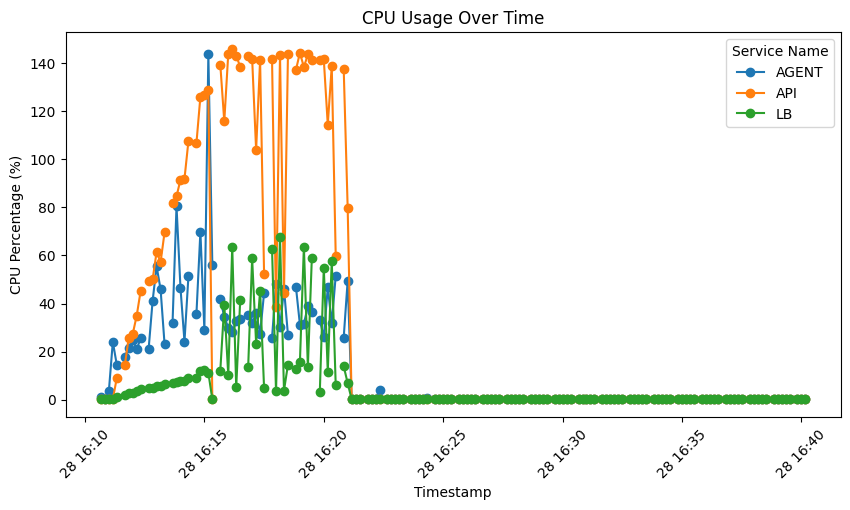

In [120]:
# 그래프 설정
plt.figure(figsize=(10, 5))

# 각 Name별로 선을 그리기
for name, group in df.groupby('Name'):
    plt.plot(group['Timestamp'], group['CPUPerc'], marker='o', linestyle='-', label=name)

# 그래프 제목 및 축 라벨
plt.title('CPU Usage Over Time')
plt.xlabel('Timestamp')
plt.ylabel('CPU Percentage (%)')
plt.xticks(rotation=45)  # x축 레이블 회전

# 범례 추가
plt.legend(title="Service Name")

# 그래프 출력
plt.show()
